In [1]:
import json

import pandas as pd
import s3fs

fs = s3fs.S3FileSystem(
    endpoint_url="https://minio.lab.sspcloud.fr",
    client_kwargs={"region_name": "us-east-1"},
)

## Exemple détaillé pour 2019

In [2]:
YEAR = 2019

In [3]:
EXTRACTION = f"s3://mateomorin/legifrance/extraction_contingent/year={YEAR}/extraction_{YEAR}.parquet"

extraction = pd.read_parquet(EXTRACTION, filesystem=fs)

n_accords = len(extraction)

## Données générales

In [4]:
presence_totale = extraction["presence_contingent_conventionnel"].sum()
presence_moyenne = round(extraction["presence_contingent_conventionnel"].mean() * 100, 2)

print(f"Sur {n_accords} accords dans le thème des heures supplémentaires en {YEAR}, {presence_totale} recensent un contingent conventionnel, soit {presence_moyenne}%.")

Sur 3056 accords dans le thème des heures supplémentaires en 2019, 1723 recensent un contingent conventionnel, soit 56.38%.


In [5]:
extraction["justif_contains_220"] = extraction["justification_ou_reserve"].str.contains("220")

presence_totale = extraction[~pd.col("presence_contingent_conventionnel")]["justif_contains_220"].sum()
presence_moyenne = round(extraction[~pd.col("presence_contingent_conventionnel")]["justif_contains_220"].mean(), 2)

print(f"Sur {n_accords} accords dans le thème des heures supplémentaires en {YEAR}, {presence_totale} rappellent simplement le contingent de 220h, soit {presence_moyenne}%.")

Sur 3056 accords dans le thème des heures supplémentaires en 2019, 95 rappellent simplement le contingent de 220h, soit 0.07%.


## Extraction des informations utiles sur les contingents

Attention, les références ne sont plus uniques s'il y a plusieurs contingents d'heures supplémentaires par accord.

In [6]:
# Decomposition par contingent et non plus par accord

contingents = extraction["contingents"].to_list()
contingents = [json.loads(chaine) for chaine in contingents]
extraction["contingents"] = contingents
extraction = extraction.explode("contingents")

df_dict = extraction["contingents"].apply(
    lambda x: x if isinstance(x, dict) else {}
).apply(pd.Series)

extraction = pd.concat([extraction.drop(columns=["contingents"]), df_dict], axis=1)

del df_dict

In [7]:
# Contingent mensuel → annuel
extraction.loc[pd.col("periode").str.contains("par mois") | pd.col("periode").str.contains("mensuel"), "nombre_heures"] *= 12
extraction.loc[pd.col("periode").str.contains("par mois") | pd.col("periode").str.contains("mensuel"), "periode"] = "anuelle (montant à chaque mois x 12)"

Attention, si le contingent est pluriannuel ce ne sera pas comptabilisé.

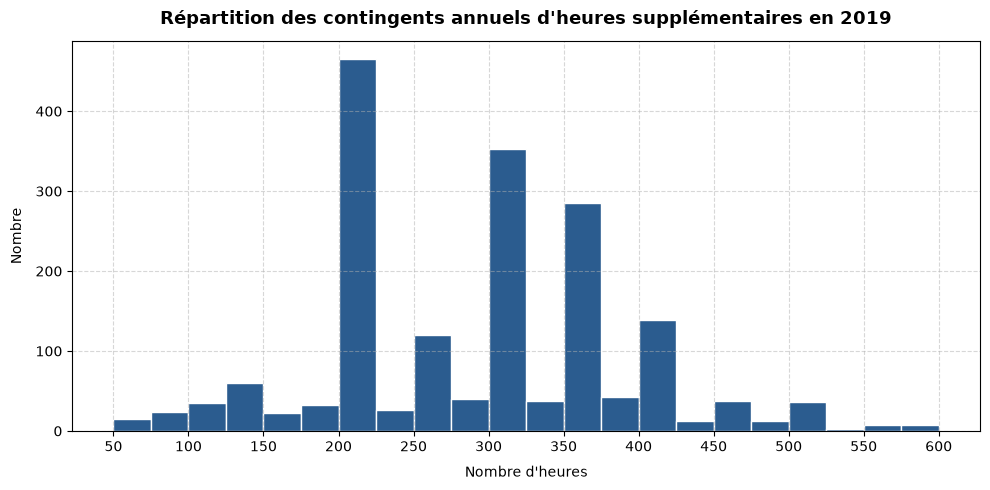

In [8]:
import matplotlib.pyplot as plt

# Définition des bornes de 50 à 600 avec un pas de 25
bins = range(50, 625, 25)

plt.figure(figsize=(10, 5))

# Filtrage entre 50 et 600 h et tracé de l'histogramme
data = extraction.query("50 <= nombre_heures <= 600")["nombre_heures"]

data.hist(
    bins=bins,
    color="#2b5c8f",
    edgecolor="white",
    grid=True,
)

plt.title(f"Répartition des contingents annuels d'heures supplémentaires en {YEAR}", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Nombre d'heures", labelpad=8)
plt.ylabel("Nombre", labelpad=8)
plt.xticks(range(50, 625, 50))  # Repères tous les 50 h pour la lisibilité
plt.grid(alpha=0.5, linestyle="--")
plt.tight_layout()
plt.show()

# Fonction principale

In [ ]:
YEAR = 2019

def present_year(YEAR):
    EXTRACTION = f"s3://mateomorin/legifrance/extraction_contingent/year={YEAR}/extraction_{YEAR}.parquet"

    extraction = pd.read_parquet(EXTRACTION, filesystem=fs)

    n_accords = len(extraction)

    presence_totale = extraction["presence_contingent_conventionnel"].sum()
    presence_moyenne = round(extraction["presence_contingent_conventionnel"].mean() * 100, 2)

    print(f"Sur {n_accords} accords dans le thème des heures supplémentaires en {YEAR}, {presence_totale} recensent un contingent conventionnel, soit {presence_moyenne}%.")
    extraction["justif_contains_220"] = extraction["justification_ou_reserve"].str.contains("220")

    presence_totale = extraction[~pd.col("presence_contingent_conventionnel")]["justif_contains_220"].sum()
    presence_moyenne = round(extraction[~pd.col("presence_contingent_conventionnel")]["justif_contains_220"].mean() * 100, 2)

    print(f"Sur {n_accords} accords dans le thème des heures supplémentaires en {YEAR}, {presence_totale} rappellent simplement le contingent de 220h, soit {presence_moyenne}% des accords restants.")

    contingents = extraction["contingents"].to_list()
    contingents = [json.loads(chaine) for chaine in contingents]
    extraction["contingents"] = contingents
    extraction = extraction.explode("contingents")

    df_dict = extraction["contingents"].apply(
        lambda x: x if isinstance(x, dict) else {}
    ).apply(pd.Series)

    extraction = pd.concat([extraction.drop(columns=["contingents"]), df_dict], axis=1)

    del df_dict

    # Contingent mensuel → annuel
    extraction.loc[pd.col("periode").str.contains("par mois") | pd.col("periode").str.contains("mensuel"), "nombre_heures"] *= 12
    extraction.loc[pd.col("periode").str.contains("par mois") | pd.col("periode").str.contains("mensuel"), "periode"] = "anuelle (montant à chaque mois x 12)"

    # Définition des bornes de 50 à 600 avec un pas de 25
    bins = range(50, 625, 25)

    plt.figure(figsize=(10, 5))

    # Filtrage entre 50 et 600 h et tracé de l'histogramme
    data = extraction.query("50 <= nombre_heures <= 600")["nombre_heures"]

    data.hist(
        bins=bins,
        color="#2b5c8f",
        edgecolor="white",
        grid=True,
    )

    plt.title(f"Répartition des contingents annuels d'heures supplémentaires en {YEAR}", fontsize=13, fontweight="bold", pad=12)
    plt.xlabel("Nombre d'heures", labelpad=8)
    plt.ylabel("Nombre de contingents mentionnés", labelpad=8)
    plt.xticks(range(50, 625, 50))
    plt.yticks(range(50, 700, 50))
    plt.grid(alpha=0.5, linestyle="--")
    plt.tight_layout()
    plt.show()

# Présentation pour chaque année

Sur 2127 accords dans le thème des heures supplémentaires en 2018, 912 recensent un contingent conventionnel, soit 42.88%.
Sur 2127 accords dans le thème des heures supplémentaires en 2018, 88 rappellent simplement le contingent de 220h, soit 7.24% des accords restants.


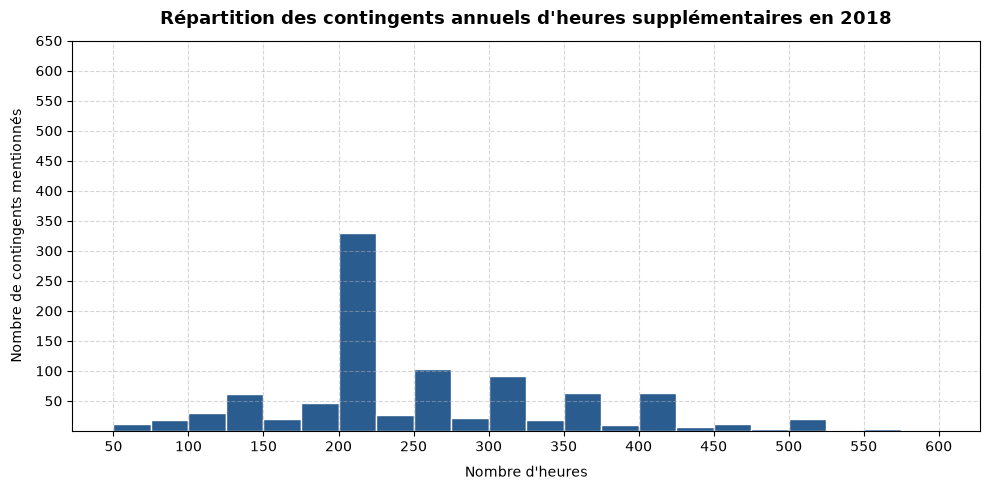

In [37]:
present_year(2018)

Sur 3056 accords dans le thème des heures supplémentaires en 2019, 1723 recensent un contingent conventionnel, soit 56.38%.
Sur 3056 accords dans le thème des heures supplémentaires en 2019, 95 rappellent simplement le contingent de 220h, soit 7.13% des accords restants.


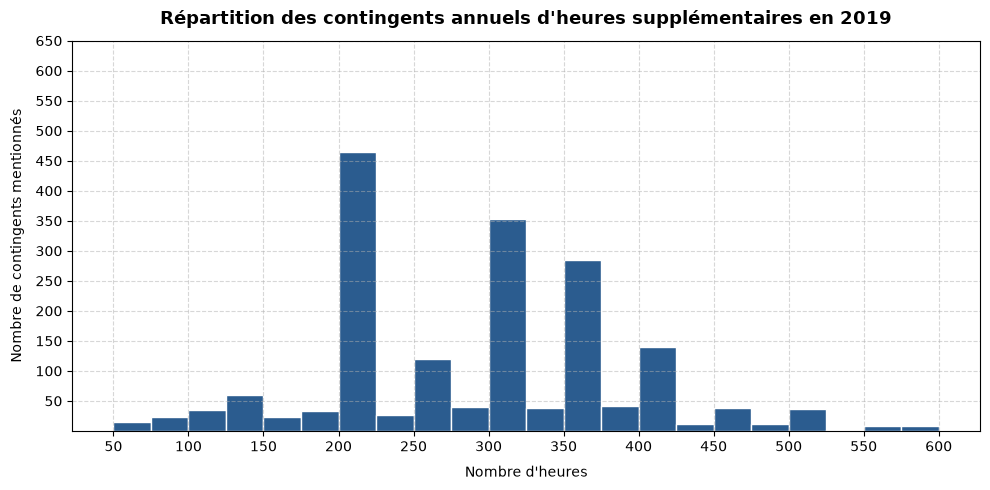

In [38]:
present_year(2019)

Sur 2745 accords dans le thème des heures supplémentaires en 2020, 1590 recensent un contingent conventionnel, soit 57.92%.
Sur 2745 accords dans le thème des heures supplémentaires en 2020, 82 rappellent simplement le contingent de 220h, soit 7.1% des accords restants.


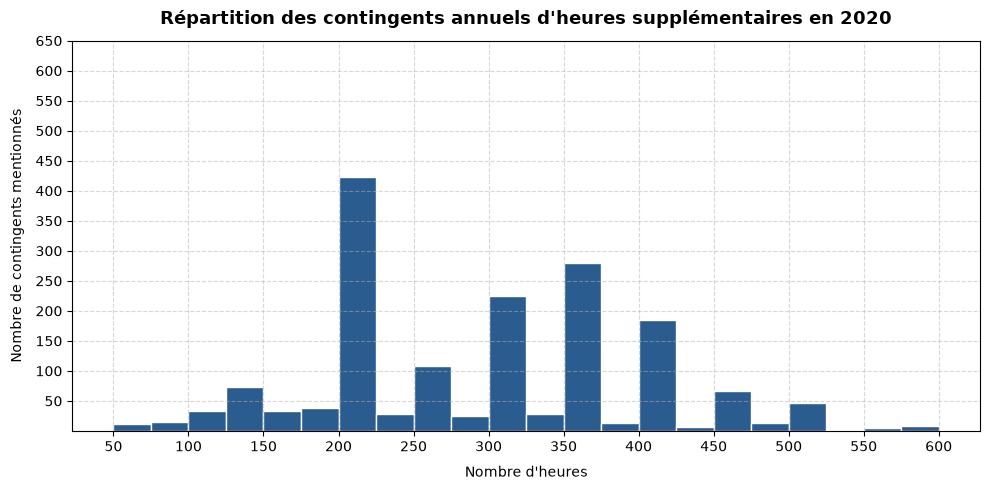

In [39]:
present_year(2020)

Sur 3057 accords dans le thème des heures supplémentaires en 2021, 1767 recensent un contingent conventionnel, soit 57.8%.
Sur 3057 accords dans le thème des heures supplémentaires en 2021, 100 rappellent simplement le contingent de 220h, soit 7.75% des accords restants.


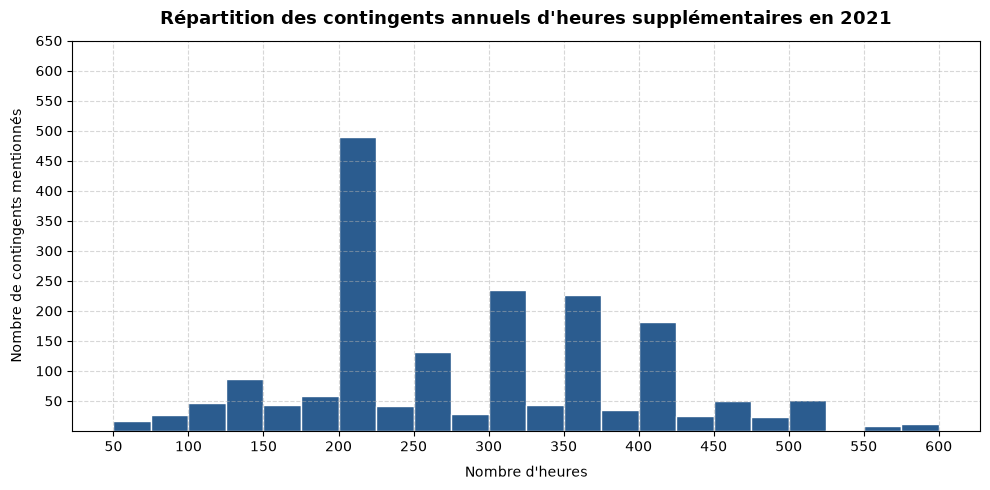

In [40]:
present_year(2021)

Sur 3185 accords dans le thème des heures supplémentaires en 2022, 1908 recensent un contingent conventionnel, soit 59.91%.
Sur 3185 accords dans le thème des heures supplémentaires en 2022, 91 rappellent simplement le contingent de 220h, soit 7.13% des accords restants.


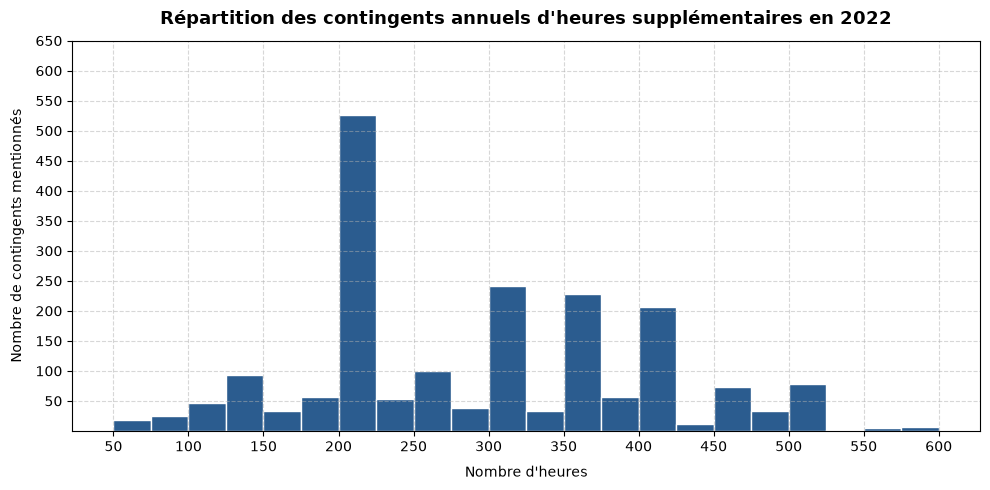

In [41]:
present_year(2022)

Sur 3590 accords dans le thème des heures supplémentaires en 2023, 2101 recensent un contingent conventionnel, soit 58.52%.
Sur 3590 accords dans le thème des heures supplémentaires en 2023, 113 rappellent simplement le contingent de 220h, soit 7.59% des accords restants.


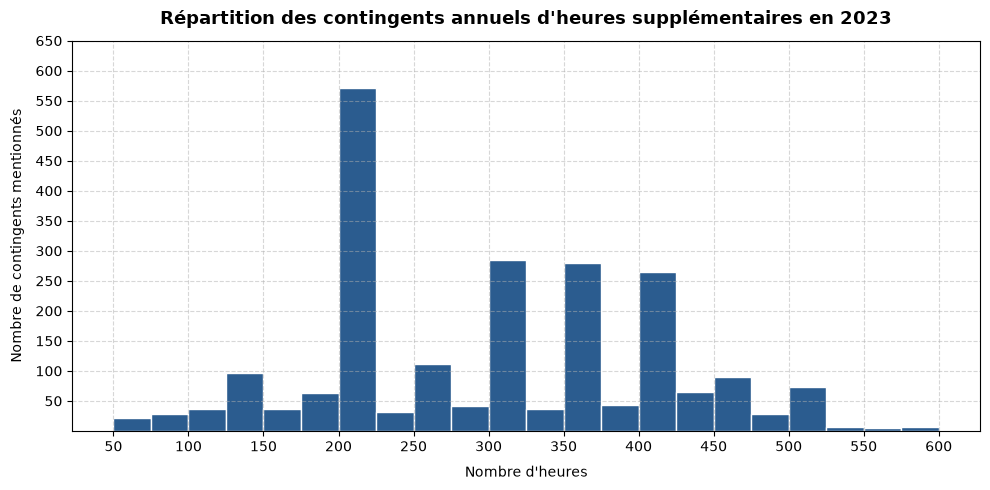

In [42]:
present_year(2023)

Sur 3805 accords dans le thème des heures supplémentaires en 2024, 2203 recensent un contingent conventionnel, soit 57.9%.
Sur 3805 accords dans le thème des heures supplémentaires en 2024, 118 rappellent simplement le contingent de 220h, soit 7.37% des accords restants.


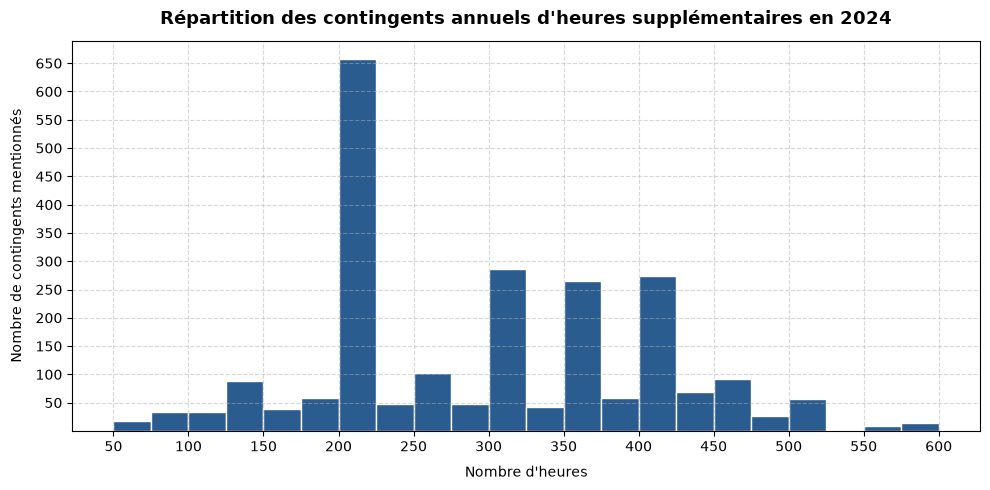

In [43]:
present_year(2024)

Sur 3609 accords dans le thème des heures supplémentaires en 2025, 2116 recensent un contingent conventionnel, soit 58.63%.
Sur 3609 accords dans le thème des heures supplémentaires en 2025, 101 rappellent simplement le contingent de 220h, soit 6.76% des accords restants.


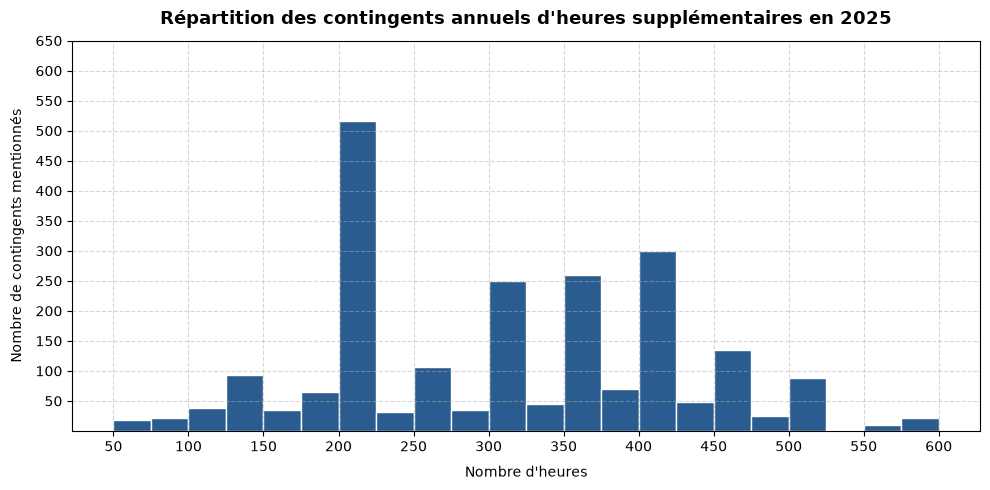

In [44]:
present_year(2025)

# Comparaison globale

In [2]:
def compute_extraction_all():
    years = list(range(2018,2026))

    extraction_all = []

    for YEAR in years:
        EXTRACTION = f"s3://mateomorin/legifrance/extraction_contingent/year={YEAR}/extraction_{YEAR}.parquet"

        extraction = pd.read_parquet(EXTRACTION, filesystem=fs)

        n_accords = len(extraction)

        presence_totale = extraction["presence_contingent_conventionnel"].sum()
        presence_moyenne = round(extraction["presence_contingent_conventionnel"].mean() * 100, 2)

        print(f"Sur {n_accords} accords dans le thème des heures supplémentaires en {YEAR}, {presence_totale} recensent un contingent conventionnel, soit {presence_moyenne}%.")
        extraction["justif_contains_220"] = extraction["justification_ou_reserve"].str.contains("220")

        presence_totale = extraction[~pd.col("presence_contingent_conventionnel")]["justif_contains_220"].sum()
        presence_moyenne = round(extraction[~pd.col("presence_contingent_conventionnel")]["justif_contains_220"].mean() * 100, 2)

        print(f"Sur {n_accords} accords dans le thème des heures supplémentaires en {YEAR}, {presence_totale} rappellent simplement le contingent de 220h, soit {presence_moyenne}% des accords restants.")

        contingents = extraction["contingents"].to_list()
        contingents = [json.loads(chaine) for chaine in contingents]
        extraction["contingents"] = contingents
        extraction = extraction.explode("contingents")

        df_dict = extraction["contingents"].apply(
            lambda x: x if isinstance(x, dict) else {}
        ).apply(pd.Series)

        extraction = pd.concat([extraction.drop(columns=["contingents"]), df_dict], axis=1)

        del df_dict

        # Contingent mensuel → annuel
        extraction.loc[pd.col("periode").str.contains("par mois") | pd.col("periode").str.contains("mensuel"), "nombre_heures"] *= 12
        extraction.loc[pd.col("periode").str.contains("par mois") | pd.col("periode").str.contains("mensuel"), "periode"] = "anuelle (montant à chaque mois x 12)"

        extraction_all.append(extraction)
    
    extraction_all = pd.concat(extraction_all)

    return extraction_all


In [3]:
extraction_all = compute_extraction_all()

Sur 2127 accords dans le thème des heures supplémentaires en 2018, 912 recensent un contingent conventionnel, soit 42.88%.
Sur 2127 accords dans le thème des heures supplémentaires en 2018, 88 rappellent simplement le contingent de 220h, soit 7.24% des accords restants.
Sur 3056 accords dans le thème des heures supplémentaires en 2019, 1723 recensent un contingent conventionnel, soit 56.38%.
Sur 3056 accords dans le thème des heures supplémentaires en 2019, 95 rappellent simplement le contingent de 220h, soit 7.13% des accords restants.
Sur 2745 accords dans le thème des heures supplémentaires en 2020, 1590 recensent un contingent conventionnel, soit 57.92%.
Sur 2745 accords dans le thème des heures supplémentaires en 2020, 82 rappellent simplement le contingent de 220h, soit 7.1% des accords restants.
Sur 3057 accords dans le thème des heures supplémentaires en 2021, 1767 recensent un contingent conventionnel, soit 57.8%.
Sur 3057 accords dans le thème des heures supplémentaires en 20

In [5]:
import plotly.express as px

data_filtered = extraction_all.query("50 <= nombre_heures <= 600")

fig = px.violin(
    data_filtered,
    x="anneeSignature",
    y="nombre_heures",
    color="anneeSignature",
    box=False,
    points="outliers",
    labels={"anneeSignature": "Année de signature", "nombre_heures": "Nombre d'heures"},
    title="<b>Répartition des contingents par année</b>",
)

fig.update_layout(
    xaxis_type="category",  # Évite les valeurs décimales sur l'axe des x
    showlegend=False,
    template="plotly_white",
    height=500,
    width=900,
)

fig.show()